In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 1
V0 = 1e-10
v0 = V0 / 24 * np.pi * np.pi
beta = 0.01
deltaPhiWell = 2 * (2 / 3 * v0 / beta) ** (1 / 3)
phi0 = 0.5 * deltaPhiWell + 0.3 / np.sqrt(beta)

def infPotFunc(phi):
    x = phi - phi0
    return float(V0 * (1 + beta * x * x * x))

def infPotDerivFunc(phi):
    x = phi - phi0
    return float(3 * V0 * beta * x * x)

def infPotDeriv2Func(phi):
    x = phi - phi0
    return float(6 * V0 * beta * x)

def etaCl(phi):
    v = infPotFunc(phi)
    vDer = infPotDerivFunc(phi)
    vDer2 = infPotDeriv2Func(phi)
    return abs(2 * v - vDer2 * v**2 / vDer**2)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

nGrid = 4096  

In [5]:
# etaCl>1の領域を探索
upperBound = bisect(lambda phi: etaCl(phi) - 1, phi0 + 0.01 * deltaPhiWell, phi0 + 10 * deltaPhiWell) 
lowerBound = bisect(lambda phi: etaCl(phi) - 1, phi0 - 10 * deltaPhiWell, phi0 - 0.01 * deltaPhiWell)
print(lowerBound, upperBound) 

2.999517512303737 3.0032816564216303


In [6]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0OriFunc"],
    ["Dirichlet"]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

c:\Users\koich\Desktop\Code\StochasticInflationDiffOpEigen\InfAdjFPFiniteDiffApp.py:156: RuntimeWarning: invalid value encountered in double_scalars
  slowrollEta = np.abs(vDers.T @ vDer2AtGrids[:,:,ig] @ vDers / vAtGrids[ig] / np.sum(vDers ** 2))


In [7]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

In [8]:
fpFinDiff_DirNeu

array([[ 1.00651504, -0.49989227,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.49989227,  1.00650198, -0.49989227, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -0.49989227,  1.00648894, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.00638916,
        -0.49989227,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -0.49989227,
         1.00640217, -0.49989227],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.99978454,  1.1220497 ]])

In [9]:
v = infPotFunc(upperBound) / 24 / np.pi**2
vDer = infPotDerivFunc(upperBound) / 24 / np.pi**2
correcFac = (1 + 1 / v) * vDer / ((upperBound - lowerBound) / nGrid)
print(correcFac)
print((upperBound - lowerBound) / nGrid)
print(vDer / v / v)

0.11563450729401446
9.189804975324838e-07
251712.47287350602


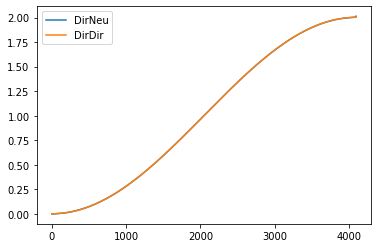

In [10]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

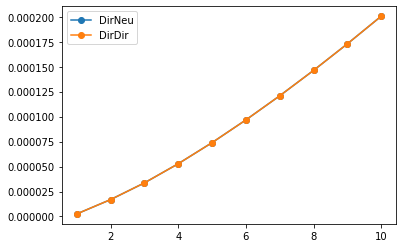

In [11]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 11), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

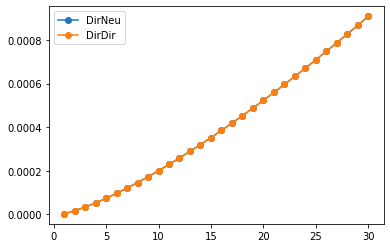

In [12]:
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu[:30], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 31), eigValsSort_DirDir[:30], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [13]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[2.56485979e-06 1.69238875e-05 3.36400788e-05 5.28293941e-05
 7.39407268e-05 9.66785773e-05 1.20838775e-04 1.46271259e-04
 1.72860172e-04 2.00512877e-04]
[2.56485980e-06 1.69238876e-05 3.36400788e-05 5.28293942e-05
 7.39407271e-05 9.66785778e-05 1.20838776e-04 1.46271260e-04
 1.72860174e-04 2.00512879e-04]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

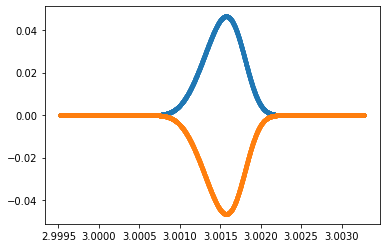

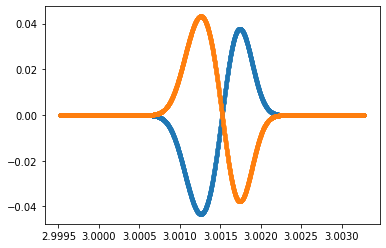

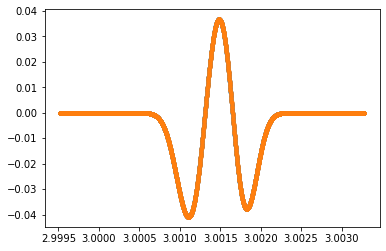

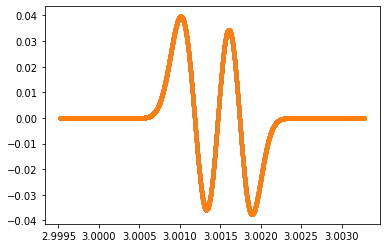

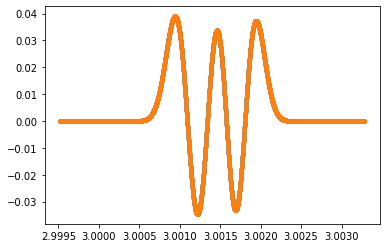

In [14]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))

ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [15]:
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

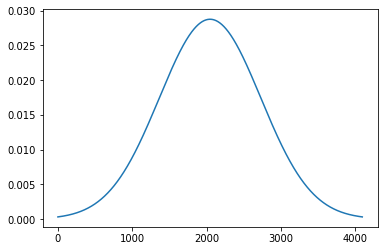

In [16]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

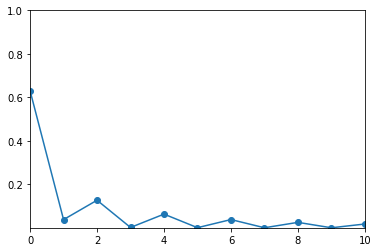

In [17]:
# 各固有ベクトルの寄与度
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort_DirDir]

ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

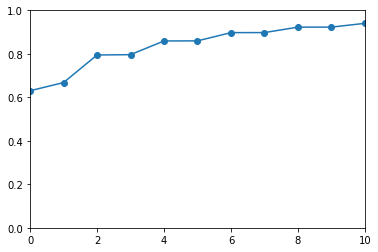

In [18]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()